# SBI Demo — 21cm Intensity Mapping

Neural Posterior Estimation (NPE-C) for the 21cm signal power spectrum P_s(k).  
Direct comparison target: `../Gibbs_2026/Gibbs_update_2.ipynb`.

## 1. Imports

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

from sbi.inference import NPE

from simulator import Simulator, load_config
from sbi_utils import make_prior, compute_summary_stats, Normaliser

/home/geoff/gibbs_venv_312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Config & Prior

In [2]:
cfg = load_config()

# Fiducial log10(P_s) per bin, measured from the true signal cube
# using the same binner() convention as the simulator.
LOG_PS_FID = np.array([
    -0.285, -0.745, -1.073, -1.313, -1.490,
    -1.626, -1.729, -1.803, -1.859, -1.913,
    -1.952, -1.990, -2.016, -2.010
])

# Per-bin log-uniform prior: fiducial ± 1.5 dex
PRIOR_HALF_WIDTH = 1.5
LOG_PS_MIN = LOG_PS_FID - PRIOR_HALF_WIDTH
LOG_PS_MAX = LOG_PS_FID + PRIOR_HALF_WIDTH

prior = make_prior(LOG_PS_MIN, LOG_PS_MAX, cfg['n_kbins'])
print('Prior low :', LOG_PS_MIN.round(2))
print('Prior high:', LOG_PS_MAX.round(2))

Prior low : [-1.78 -2.24 -2.57 -2.81 -2.99 -3.13 -3.23 -3.3  -3.36 -3.41 -3.45 -3.49
 -3.52 -3.51]
Prior high: [ 1.22  0.76  0.43  0.19  0.01 -0.13 -0.23 -0.3  -0.36 -0.41 -0.45 -0.49
 -0.52 -0.51]


## 3. Setup Simulator

In [3]:
sim = Simulator(cfg)
sim.setup()
print('U_f shape :', sim.U_f.shape)
print('a_true shape:', sim.a_true.shape)

U_f shape : (4, 128)
a_true shape: (16384, 4)


## 4. Prior Predictive Check

Draw a handful of (θ, x) pairs and inspect the data cubes and summary statistics
before committing to a full training run.

In [4]:
N_PPC = 5
np.random.seed(0)
thetas_ppc = prior.sample((N_PPC,)).numpy()   # (N_PPC, n_kbins)

xs_ppc = []
for th in thetas_ppc:
    xs_ppc.append(sim(th))
xs_ppc = np.array(xs_ppc)                      # (N_PPC, n_summary)
print('xs_ppc shape:', xs_ppc.shape)

xs_ppc shape: (5, 24)


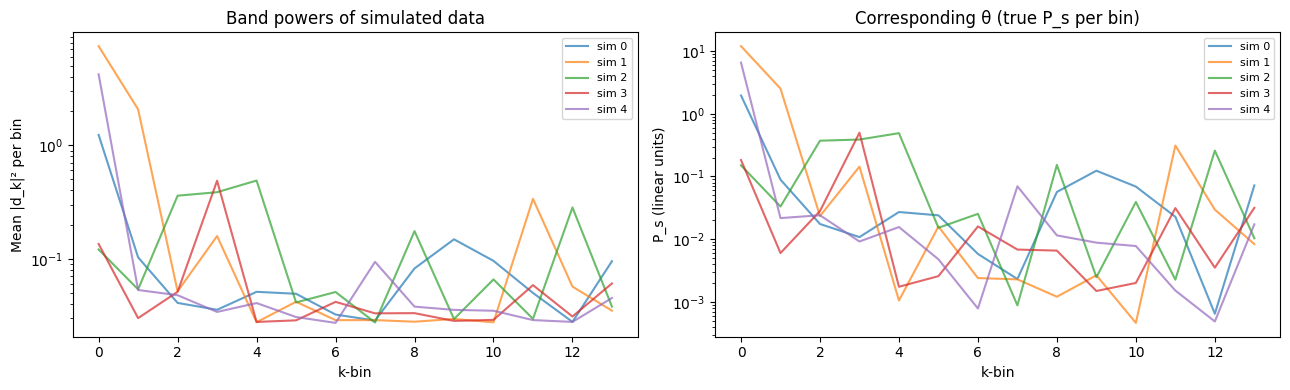

In [5]:
# --- Plot band powers vs true theta ---
n_kbins = cfg['n_kbins']
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
for i, (th, x) in enumerate(zip(thetas_ppc, xs_ppc)):
    ax.plot(range(n_kbins), x[:n_kbins], alpha=0.7, label=f'sim {i}')
ax.set_yscale('log')
ax.set_xlabel('k-bin')
ax.set_ylabel('Mean |d_k|² per bin')
ax.set_title('Band powers of simulated data')
ax.legend(fontsize=8)

ax = axes[1]
for i, (th, x) in enumerate(zip(thetas_ppc, xs_ppc)):
    ax.plot(range(n_kbins), 10**th, alpha=0.7, label=f'sim {i}')
ax.set_yscale('log')
ax.set_xlabel('k-bin')
ax.set_ylabel('P_s (linear units)')
ax.set_title('Corresponding θ (true P_s per bin)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 5. Generate Training Simulations

Target: ~20 000 simulations. The simulator is embarrassingly parallel.  
**Note:** this cell is slow — run it once and save the arrays.

In [6]:
N_TRAIN = 20_000
N_JOBS  = -1          # use all available CPUs

thetas_train = prior.sample((N_TRAIN,)).numpy()   # (N_TRAIN, n_kbins)

xs_train = np.array(
    Parallel(n_jobs=N_JOBS, verbose=10)(
        delayed(sim)(th) for th in thetas_train
    )
)                                                  # (N_TRAIN, n_summary)
print('xs_train shape:', xs_train.shape)

np.save('outputs/thetas_train.npy', thetas_train)
np.save('outputs/xs_train.npy', xs_train)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.


[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    8.5s
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:   14.7s
[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:   20.9s
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:   28.2s
[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed:   36.9s
[Parallel(n_jobs=-1)]: Done  48 tasks      | elapsed:   41.9s
[Parallel(n_jobs=-1)]: Done  61 tasks      | elapsed:   54.3s
[Parallel(n_jobs=-1)]: Done  74 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done  89 tasks      | elapsed:  1.3min
[Parallel(n_jobs=-1)]: Done 104 tasks      | elapsed:  1.5min
[Parallel(n_jobs=-1)]: Done 121 tasks      | elapsed:  1.7min
[Parallel(n_jobs=-1)]: Done 138 tasks      | elapsed:  1.9min
[Parallel(n_jobs=-1)]: Done 157 tasks      | elapsed:  2.2min
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:  2.5min
[Parallel(n_jobs=-1)]: Done 197 tasks      | elapsed:  2.8min
[Parallel(n_jobs=-1)]: Done 218 tasks      | elapsed:  3.0min
[Paralle

KeyboardInterrupt: 

## 6. Fit Normaliser

In [ ]:
# Load from disk if already generated
thetas_train = np.load('outputs/thetas_train.npy')
xs_train     = np.load('outputs/xs_train.npy')

norm = Normaliser()
xs_norm = norm.fit_transform(xs_train)

print('xs_norm mean (should be ≈0):', xs_norm.mean(axis=0)[:5].round(3))
print('xs_norm std  (should be ≈1):', xs_norm.std(axis=0)[:5].round(3))

xs_norm mean (should be ≈0): [ 0. -0.  0. -0.  0.]
xs_norm std  (should be ≈1): [1. 1. 1. 1. 1.]


In [33]:
import numpy as np
xs = np.load('outputs/xs_train.npy')
print(xs.shape, xs[0, 0])   # expect (20000, 24) and a value ~1e-1, not ~1e5

(20000, 24) 6.908086503782657


## 7. Train NPE

Uses `sbi` NPE-C with the default masked autoregressive flow (MAF).  
**Note:** this cell is slow.

In [34]:
inference = NPE(prior=prior)
inference.append_simulations(
    torch.from_numpy(thetas_train).float(),
    torch.from_numpy(xs_norm).float(),
)
density_estimator = inference.train()
posterior = inference.build_posterior(density_estimator)
print('Training complete.')

/home/geoff/gibbs_venv_312/lib/python3.12/site-packages/sbi/inference/trainers/npe/npe_base.py:196: UserWarning: Data has extreme outliers in dimension(s) [22] (beyond 10.0x IQR from quartiles). This may cause precision loss during z-scoring, where distinct values become indistinguishable. Consider removing outliers from your data or setting `z_score_x='none'` (though this may affect training).
  warn_if_invalid_for_zscoring(x)


 Neural network successfully converged after 386 epochs.Training complete.


## 8. Run on Observed Data

Load the same observation used in Gibbs_update_2 and compute x_obs.

In [35]:
# Build the same observed data cube as Gibbs_update_2
N = cfg['shape'][0]
np.random.seed(1)   # match the seed used in Gibbs_update_2

signal_true = np.load(cfg['data_dir'] + '/' + cfg['signal_file'])[:N, :N, :N].astype(float)
fg_true     = np.load(cfg['data_dir'] + '/' + cfg['fg_file'])[:N, :N, :N].astype(float)
noise_obs   = np.random.normal(0.0, cfg['noise_std'], cfg['shape'])
d_obs       = signal_true + fg_true + noise_obs

binner_args = dict(n_kbins=cfg['n_kbins'], cube_len=N)
x_obs      = compute_summary_stats(d_obs, binner_args, sim.U_f)
x_obs_norm = norm.transform(x_obs[None])[0]
x_tensor   = torch.from_numpy(x_obs_norm).float()

# posterior.sample() applies a prior-support rejection step.  With tight
# per-bin BoxUniform priors the flow can produce samples just outside the
# bounds, giving near-zero acceptance.  Fix: rebuild the posterior with
# bounds wide enough (~±20 dex) that nothing the flow produces will ever
# be rejected.  The training and the flow are unchanged; only the rejection
# gate is widened.
from sbi.utils import BoxUniform
n_kbins   = cfg['n_kbins']
flat_prior = BoxUniform(
    low =torch.full((n_kbins,), -20.0),
    high=torch.full((n_kbins,),  20.0),
)
posterior_sample = inference.build_posterior(density_estimator, prior=flat_prior)

N_SAMPLES = 10_000
samples = posterior_sample.sample((N_SAMPLES,), x=x_tensor).numpy()
print('Posterior samples shape:', samples.shape)

                    accepted. It may take a long time to collect the remaining
                    10000 samples. You can prevent very long runtimes by
                    setting `max_sampling_time` to limit runtime, or disabling
                    rejection sampling (e.g. via `reject_outside_prior=False` in
                    `posterior.sample()` when available).Alternatively, consider interrupting (Ctrl-C)
                    and switching to `build_posterior(..., sample_with='mcmc')`.
  0%|          | 0/10000 [28:26<?, ?it/s]


KeyboardInterrupt: 

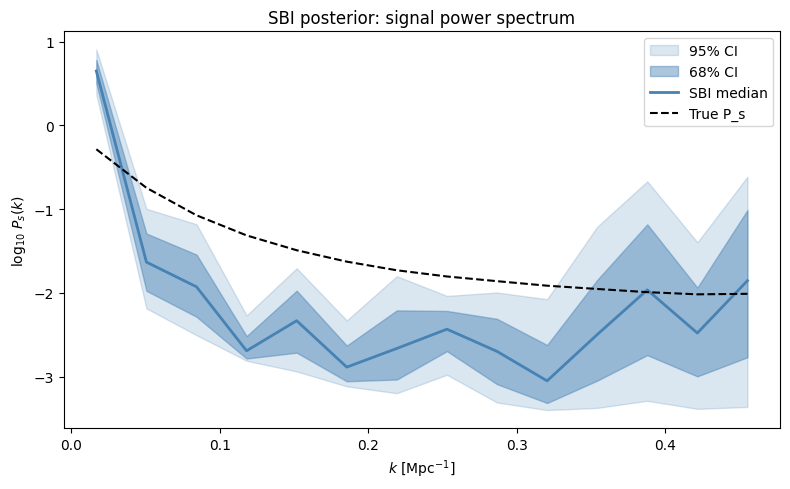

In [7]:
# --- k-bin centres in physical units ---
# binner() uses linear pixel-unit bins from k=0 to the corner mode k=N/2 * sqrt(3).
# Convert pixel -> Mpc^-1 via k_phys = k_pix * 2π / L.
N = cfg['shape'][0]
L = cfg['box_dims'][0]                                    # Mpc
k_pix_max = (N / 2) * np.sqrt(3)                         # corner mode, pixel units
kbins     = np.linspace(0, k_pix_max, cfg['n_kbins'] + 1)
k_mpc     = (kbins[:-1] + kbins[1:]) / 2 * (2 * np.pi / L)  # Mpc^-1

# --- Posterior percentiles (θ = log10 P_s per bin) ---
pct_16, pct_50, pct_84         = np.percentile(samples, [16, 50, 84], axis=0)
pct_025, pct_975               = np.percentile(samples, [2.5, 97.5], axis=0)

fig, ax = plt.subplots(figsize=(8, 5))

ax.fill_between(k_mpc, pct_025, pct_975,
                alpha=0.20, color='steelblue', label='95% CI')
ax.fill_between(k_mpc, pct_16, pct_84,
                alpha=0.45, color='steelblue', label='68% CI')
ax.plot(k_mpc, pct_50,   color='steelblue', lw=2,   label='SBI median')
ax.plot(k_mpc, LOG_PS_FID, 'k--', lw=1.5, label='True P_s')

ax.set_xlabel(r'$k$ [Mpc$^{-1}$]')
ax.set_ylabel(r'$\log_{10}\,P_s(k)$')
ax.set_title('SBI posterior: signal power spectrum')
ax.legend()
plt.tight_layout()
plt.show()

## 9. Compare to Gibbs

Overlay the SBI P_s posterior with Gibbs chain marginals.

In [8]:
import glob

# Load Gibbs Pk trace — adjust glob pattern to match your outputs directory
gibbs_files = sorted(glob.glob('../Gibbs_2026/outputs/samples/Pk_trace_*.npy'))
if gibbs_files:
    gibbs_pk = np.concatenate([np.load(f) for f in gibbs_files], axis=0)
    burnin = len(gibbs_pk) // 5          # discard first 20%
    gibbs_pk = gibbs_pk[burnin:]         # (n_samples, n_kbins)
    print('Gibbs samples (post-burnin):', gibbs_pk.shape)
else:
    gibbs_pk = None
    print('No Gibbs samples found — skipping overlay.')

fig, axes = plt.subplots(2, n_kbins // 2, figsize=(16, 6))
axes = axes.flatten()

for b in range(n_kbins):
    ax = axes[b]
    ax.hist(samples[:, b], bins=40, density=True,
            alpha=0.6, color='steelblue', label='SBI')
    if gibbs_pk is not None:
        ax.hist(np.log10(gibbs_pk[:, b]), bins=40, density=True,
                alpha=0.6, color='orange', label='Gibbs')
    ax.axvline(LOG_PS_FID[b], color='k', ls='--', lw=1, label='Truth')
    ax.set_title(f'bin {b}', fontsize=9)
    ax.tick_params(labelsize=7)
    if b == 0:
        ax.legend(fontsize=7)

plt.suptitle('SBI vs Gibbs: log10 P_s per k-bin', y=1.01)
plt.tight_layout()
plt.show()

No Gibbs samples found — skipping overlay.


NameError: name 'n_kbins' is not defined

## 10. Simulation-Based Calibration (SBC)

Check that the posterior is well-calibrated across the prior.  
Flag any k-bins where coverage is off.

In [12]:
from sbi.diagnostics import check_sbc, run_sbc

N_SBC = 1_000
thetas_sbc = prior.sample((N_SBC,))
xs_sbc_raw = np.array([sim(th.numpy()) for th in thetas_sbc])
xs_sbc     = torch.from_numpy(norm.transform(xs_sbc_raw)).float()

ranks, dap_samples = run_sbc(
    thetas_sbc, xs_sbc, posterior,
    num_posterior_samples=1_000,
)
check_stats = check_sbc(
    ranks, thetas_sbc, dap_samples,
    num_posterior_samples=1_000,
)
print(check_stats)

/home/geoff/gibbs_venv_312/lib/python3.12/site-packages/sbi/utils/diagnostics_utils.py:45: UserWarning: Capping max_sampling_batch_size from 10000 to 100 to avoid excessive memory usage.
  posterior_samples = posterior.sample_batched(
Drawing 1000 samples for 1000 observations:   0%|          | 1/1000 [00:07<2:04:41,  7.49s/it]WARNING:root:Only 1.000% proposal samples are
                    accepted. It may take a long time to collect the remaining
                    999 samples. You can prevent very long runtimes by
                    setting `max_sampling_time` to limit runtime, or disabling
                    rejection sampling (e.g. via `reject_outside_prior=False` in
                    `posterior.sample()` when available).Alternatively, consider interrupting (Ctrl-C)
                    and switching to `build_posterior(..., sample_with='mcmc')`.
Drawing 1000 samples for 1000 observations:   5%|▍         | 46/1000 [05:38<2:08:36,  8.09s/it]

KeyboardInterrupt: 